# 🏛️ BMC — Descarga y Extracción de Boletines Diarios
**Proyecto:** HCH Intelligence Dashboard | **Autora:** Natalia Vindrola Muñoz

### Orden de ejecución:
1. **Celda 1** — Instalación (solo la primera vez)
2. **Celda 2** — Imports y configuración
3. **Celda 3** — Inicializar DB
4. **Celda 4** — Funciones de extracción OCR
5. **Celda 5** — Función de descarga Playwright
6. **Celda 6** — ▶️ DESCARGA HISTÓRICA (dejar corriendo toda la noche)
7. **Celda 7** — ▶️ Extracción masiva a DB (correr después de la descarga)
8. **Celda 8** — Verificar resultados
9. **Celda 9** — Gráfico precio HCH
10. **Celda 10** — Actualización diaria (correr cada día)

In [19]:
# ── CELDA 1 — Instalación (solo la primera vez) ──────────────────
import sys
!{sys.executable} -m pip install pdfplumber nest_asyncio playwright pytesseract pdf2image pillow
!playwright install chromium

Update de mercado_hch

In [1]:
import sqlite3

DB_PATH = "mercado_hch.db"
con = sqlite3.connect(DB_PATH)
cur = con.cursor()

# Ver todas las tablas
cur.execute("SELECT name FROM sqlite_master WHERE type='table'")
tablas = cur.fetchall()
print("TABLAS:", tablas)

# Ver columnas de cada tabla
for tabla in tablas:
    nombre = tabla[0]
    cur.execute(f"PRAGMA table_info({nombre})")
    cols = cur.fetchall()
    print(f"\nCOLUMNAS de '{nombre}':")
    for c in cols:
        print(f"  {c[1]} ({c[2]})")

# Ver 3 filas de muestra de cada tabla
for tabla in tablas:
    nombre = tabla[0]
    cur.execute(f"SELECT * FROM {nombre} LIMIT 3")
    rows = cur.fetchall()
    print(f"\nMUESTRA de '{nombre}':")
    for r in rows:
        print(" ", r)

con.close()

TABLAS: [('dian_2026',), ('bmc_precios',), ('sqlite_sequence',), ('hch_precio_unificado',), ('hch_forecast_xgb_v2',), ('ingredientes_comparacion',), ('bmc_precios_correcciones_log',), ('bmc_precios_limpio',), ('importaciones_limpias',), ('importaciones',), ('trm_diaria',), ('cme_diario',), ('roni_mensual',), ('sacrificio_bovino',)]

COLUMNAS de 'dian_2026':
  SUBPARTIDA_ARANCELARIA (TEXT)
  FECHA_ACEPTACION_DECLARACION (TEXT)
  PAIS_ORIGEN (TEXT)
  PAIS_PROCEDENCIA (TEXT)
  PESO_NETO (REAL)
  VALOR_CIF_USD (REAL)
  VALOR_FOB_USD (TEXT)
  VALOR_FLETES_USD (TEXT)
  DEPARTAMENTO_DESTINO (TEXT)
  MODO_TRANSPORTE (TEXT)
  NOMBRE_IMPORTADOR (TEXT)
  DESCRIPCION_MERCANCIA (TEXT)
  TASA_CAMBIO (REAL)
  PESO_TON (REAL)
  PRECIO_USD_TON (REAL)
  PRECIO_COP_TON (REAL)
  FECHA (TIMESTAMP)
  PRODUCTO (TEXT)
  FUENTE (TEXT)

COLUMNAS de 'bmc_precios':
  id (INTEGER)
  fecha (TEXT)
  n_rueda (INTEGER)
  producto_bmc (TEXT)
  producto (TEXT)
  unidad (TEXT)
  cantidad_kg (REAL)
  total_cop (REAL)
  pr

Inicio

In [3]:
# ── CELDA 2 — Imports y configuración ────────────────────────────
import asyncio
import sqlite3
import re
import nest_asyncio
from pathlib import Path
from datetime import date, datetime

import pandas as pd
import pytesseract
from pdf2image import convert_from_path

nest_asyncio.apply()

# ─── CONFIGURA AQUÍ ───────────────────────────────────────────────
DB_PATH      = "mercado_hch.db"
CARPETA_PDF  = Path("./boletines_bmc")
TRM_FALLBACK = 4200.0 
URL_PORTAL   = "https://bpmapps.bolsamercantil.com.co/Boletines/Boletines.aspx"
TESSERACT    = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
POPPLER_PATH = r"C:\poppler\Library\bin"

pytesseract.pytesseract.tesseract_cmd = TESSERACT
CARPETA_PDF.mkdir(parents=True, exist_ok=True)

# ── NUEVO: cargar TRM real por fecha en memoria (evita golpear la BD por cada PDF) ──
with sqlite3.connect(DB_PATH) as _con:
    _df_trm = pd.read_sql("SELECT fecha, trm_cop_usd FROM trm_diaria", _con)
TRM_POR_FECHA = dict(zip(_df_trm['fecha'], _df_trm['trm_cop_usd']))

def obtener_trm(fecha_str):
    """Devuelve la TRM real para una fecha (YYYY-MM-DD). Si no existe, usa el fallback."""
    return TRM_POR_FECHA.get(fecha_str, TRM_FALLBACK)

PRODUCTOS_OBJETIVO = [
    "HARINA DE CARNE Y HUESO",
    "SUBPRODUCTOS CARNICOS",
    "SEBO DE RES",
    
    "HARINA DE HUESO",
    "FOSFATO MONODICALCICO",
    
    "HARINA DE PLUMA",
    "HARINA DE VISCERAS",
    "HARINA DE SANGRE",
            
    "TORTA DE SOYA IMPORTADA", 
    "ALIMENTO CONCENTRADO PARA AVES",
    "ALIMENTO CONCENTRADO PARA CERDOS",
    "ALIMENTO CONCENTRADO PARA GATOS",
    "ALIMENTO CONCENTRADO PARA PERROS"
]

NOMBRE_CORTO = {
    "HARINA DE CARNE Y HUESO": "HCH",
    "SUBPRODUCTOS CARNICOS":    "subproductos_carnicos",
    "SEBO DE RES":             "sebo_res",
    
    "HARINA DE HUESO":          "harina_hueso",
    "HARINA DE VISCERAS":      "harina_visceras",
    "HARINA DE SANGRE":        "harina_sangre",
    "HARINA DE PLUMA":         "harina_pluma_sangre",
    
    "TORTA DE SOYA IMPORTADA": "torta_soya_importada",
    "FOSFATO MONODICALCICO":     "fosfato_monodicalcico",
    "ALIMENTO CONCENTRADO PARA AVES": "concentrado_aves",
    "ALIMENTO CONCENTRADO PARA CERDOS": "concentrado_cerdos",
    "ALIMENTO CONCENTRADO PARA GATOS": "concentrado_gatos",
    "ALIMENTO CONCENTRADO PARA PERROS": "concentrado_perros"
    
    
}

MESES_ES = {
    "ENERO":1,"FEBRERO":2,"MARZO":3,"ABRIL":4,"MAYO":5,"JUNIO":6,
    "JULIO":7,"AGOSTO":8,"SEPTIEMBRE":9,"OCTUBRE":10,"NOVIEMBRE":11,"DICIEMBRE":12
}

print("✅ Configuración lista")
print(f"   DB:      {DB_PATH}")
print(f"   PDFs:    {CARPETA_PDF.resolve()}")
print(f"   TRM:     dinámica por fecha ({len(TRM_POR_FECHA)} fechas cargadas, fallback={TRM_FALLBACK})")

✅ Configuración lista
   DB:      mercado_hch.db
   PDFs:    C:\Users\nvind\OneDrive\Documentos\Tesis+trabajo+python\Documents\Proyecto-hnacarnehueso\boletines_bmc
   TRM:     dinámica por fecha (1668 fechas cargadas, fallback=4200.0)


In [5]:
# ── CELDA 3 — Inicializar DB ──────────────────────────────────────
def init_db():
    with sqlite3.connect(DB_PATH) as con:
        con.execute("""
            CREATE TABLE IF NOT EXISTS bmc_precios (
                id              INTEGER PRIMARY KEY AUTOINCREMENT,
                fecha           TEXT NOT NULL,
                n_rueda         INTEGER,
                producto_bmc    TEXT NOT NULL,
                producto        TEXT NOT NULL,
                unidad          TEXT,
                cantidad_kg     REAL,
                total_cop       REAL,
                precio_cop_kg   REAL,
                precio_usd_ton  REAL,
                trm             REAL,
                n_subastadores  INTEGER,
                archivo_pdf     TEXT,
                UNIQUE(fecha, producto_bmc)
            )
        """)
        con.commit()
    with sqlite3.connect(DB_PATH) as con:
        tablas = __import__('pandas').read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)
    print("✅ Tabla bmc_precios lista")
    print("   Tablas en DB:", list(tablas['name']))

init_db()

✅ Tabla bmc_precios lista
   Tablas en DB: ['dian_2026', 'bmc_precios', 'sqlite_sequence', 'hch_precio_unificado', 'hch_forecast_xgb_v2', 'ingredientes_comparacion', 'bmc_precios_correcciones_log', 'bmc_precios_limpio', 'importaciones_limpias', 'importaciones', 'trm_diaria', 'cme_diario', 'roni_mensual', 'sacrificio_bovino']


In [7]:
# ── CELDA 4 — Funciones de extracción OCR ────────────────────────


def extraer_fecha_y_rueda(nombre_pdf):
    nombre = Path(nombre_pdf).stem.upper()
    m_rueda = re.search(r'N-[_\s]*(\d+)', nombre)
    n_rueda = int(m_rueda.group(1)) if m_rueda else None
    m_fecha = re.search(
        r'DEL[_\s]+(\d{1,2})[_\s]+DE[_\s]+(\w+)[_\s]+DE[_\s]+(\d{4})', nombre
    )
    if m_fecha:
        dia  = int(m_fecha.group(1))
        mes  = MESES_ES.get(m_fecha.group(2), 0)
        anio = int(m_fecha.group(3))
        if mes:
            return f"{anio:04d}-{mes:02d}-{dia:02d}", n_rueda
    return None, n_rueda


def a_float(s):
    """
    Maneja formato colombiano y americano:
    '1.500'     → 1500.0  (punto = miles colombiano)
    '1,500'     → 1500.0  (coma = miles americano)
    '1.500,50'  → 1500.50 (colombiano con decimales)
    '1,500.50'  → 1500.50 (americano con decimales)
    """
    s = s.strip()
    if ',' in s and '.' in s:
        if s.index('.') < s.index(','):
            s = s.replace('.', '').replace(',', '.')
        else:
            s = s.replace(',', '')
    elif ',' in s:
        s = s.replace(',', '')
    elif '.' in s:
        partes = s.split('.')
        if len(partes[-1]) == 3:
            s = s.replace('.', '')
    return float(s)


def parsear_linea_bmc(linea, fecha_boletin=None):
    linea = linea.strip()
    if not linea:
        return None
    nombre_upper = linea.upper()
    match_prod = None
    for objetivo in PRODUCTOS_OBJETIVO:
        if objetivo in nombre_upper:
            match_prod = objetivo
            break
    if not match_prod:
        return None
    m_um = re.search(r'\b(KG|LT|UND|LOTE)\b', linea.upper())
    unidad = m_um.group(1) if m_um else ""
    resto  = linea[m_um.end():] if m_um else linea
    numeros = re.findall(r'\d{1,3}(?:,\d{3})*(?:\.\d+)?|\d+(?:\.\d+)?', resto)

    if len(numeros) < 3:
        return None
    try:
        cantidad_kg = a_float(numeros[0])
        total_cop   = a_float(numeros[1])
        precio_cop  = a_float(numeros[2])
        n_subast    = int(float(numeros[3])) if len(numeros) > 3 else None
    except:
        return None

    # ── TRM dinámica según la fecha real del boletín ──────────────
    trm_usada = obtener_trm(fecha_boletin) if fecha_boletin else TRM_FALLBACK
    precio_usd_ton = round((precio_cop / trm_usada) * 1000, 2) if precio_cop else None

    return {
        "producto_bmc":   match_prod,
        "producto":       NOMBRE_CORTO.get(match_prod, match_prod.lower()),
        "unidad":         unidad,
        "cantidad_kg":    cantidad_kg,
        "total_cop":      total_cop,
        "precio_cop_kg":  precio_cop,
        "precio_usd_ton": precio_usd_ton,
        "n_subastadores": n_subast,
        "trm":            trm_usada,
    }


def extraer_pdf_completo(ruta_pdf):
    fecha, n_rueda = extraer_fecha_y_rueda(ruta_pdf)
    paginas = convert_from_path(str(ruta_pdf), dpi=200, poppler_path=POPPLER_PATH)
    registros = []
    for pag in paginas:
        texto_pag = pytesseract.image_to_string(pag, lang='spa')
        for linea in texto_pag.split('\n'):
            r = parsear_linea_bmc(linea, fecha_boletin=fecha)
            if r:
                r['fecha']       = fecha
                r['n_rueda']     = n_rueda
                r['archivo_pdf'] = Path(ruta_pdf).name
                registros.append(r)
    df = pd.DataFrame(registros)
    if not df.empty:
        df = df.drop_duplicates(subset=['producto_bmc'])
    return df.to_dict('records') if not df.empty else []


def guardar_en_db(registros):
    if not registros:
        return 0
    nuevos = 0
    with sqlite3.connect(DB_PATH) as con:
        for r in registros:
            try:
                con.execute("""
                    INSERT OR IGNORE INTO bmc_precios
                    (fecha, n_rueda, producto_bmc, producto, unidad,
                     cantidad_kg, total_cop, precio_cop_kg, precio_usd_ton,
                     trm, n_subastadores, archivo_pdf)
                    VALUES
                    (:fecha, :n_rueda, :producto_bmc, :producto, :unidad,
                     :cantidad_kg, :total_cop, :precio_cop_kg, :precio_usd_ton,
                     :trm, :n_subastadores, :archivo_pdf)
                """, r)
                nuevos += con.execute("SELECT changes()").fetchone()[0]
            except Exception as e:
                print(f"  ⚠️  Error insertando: {e}")
        con.commit()
    return nuevos

print("✅ Funciones de extracción listas (TRM dinámica por fecha)")

✅ Funciones de extracción listas (TRM dinámica por fecha)


In [9]:
# ── CELDA 5 — Función de descarga Playwright ──────────────────────

async def descargar_boletines(fecha_desde_str="01/01/2024", fecha_hasta_str=None):
    from playwright.async_api import async_playwright

    if fecha_hasta_str is None:
        fecha_hasta_str = date.today().strftime("%d/%m/%Y")

    CARPETA_PDF.mkdir(parents=True, exist_ok=True)
    ya_en_disco = {p.name for p in CARPETA_PDF.glob("*.pdf")}
    descargados = []

    print(f"🌐 Conectando al portal BMC...")
    print(f"   Período: {fecha_desde_str} → {fecha_hasta_str}")
    print(f"   PDFs ya en disco: {len(ya_en_disco)}")

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(accept_downloads=True)
        page    = await context.new_page()

        await page.goto(URL_PORTAL, wait_until="networkidle", timeout=30000)
        await page.wait_for_timeout(2000)

        await page.select_option('#selBoletin', value="1180")
        await page.wait_for_timeout(3000)

        pagina_actual = 1
        while True:
            filas = await page.query_selector_all("table tbody tr")
            print(f"\n📄 Página {pagina_actual} — {len(filas)} boletines")

            for fila in filas:
                nombre_pdf = await fila.get_attribute('nombredocumento')
                if not nombre_pdf:
                    continue
                if nombre_pdf in ya_en_disco:
                    print(f"  ⏭️  Ya existe: {nombre_pdf[:65]}")
                    continue

                btn = await fila.query_selector('#btnDocumento')
                if not btn:
                    continue

                try:
                    async with page.expect_download(timeout=20000) as dl_info:
                        await btn.click()
                    dl   = await dl_info.value
                    ruta = CARPETA_PDF / nombre_pdf
                    await dl.save_as(str(ruta))
                    descargados.append(nombre_pdf)
                    ya_en_disco.add(nombre_pdf)
                    print(f"  ✅ {nombre_pdf[:70]}")
                    await page.wait_for_timeout(800)
                except Exception as e:
                    print(f"  ⚠️  Error: {nombre_pdf[:50]} → {e}")

            siguiente = await page.query_selector('a.paginate_button.next:not(.disabled)')
            if not siguiente:
                print("\n✅ Última página alcanzada")
                break
            await siguiente.click()
            await page.wait_for_timeout(2000)
            pagina_actual += 1

        await browser.close()

    print(f"\n🎉 Descarga completa: {len(descargados)} PDFs nuevos")
    print(f"   Total en disco: {len(list(CARPETA_PDF.glob('*.pdf')))} PDFs")
    return descargados

print("✅ Función de descarga lista")

✅ Función de descarga lista


In [10]:
# ── CELDA 6 — ▶️ DESCARGA HISTÓRICA (dejar corriendo toda la noche)
# Descarga todos los boletines desde 2024 hasta hoy
# Tiempo estimado: 45-90 minutos

descargados = await descargar_boletines(fecha_desde_str="01/01/2024")
print(f"\n✅ Listo. {len(descargados)} PDFs descargados esta sesión.")

🌐 Conectando al portal BMC...
   Período: 01/01/2024 → 01/06/2026
   PDFs ya en disco: 0

📄 Página 1 — 20 boletines
  ✅ BDR_100_DIARIO DE RUEDA N- 100 DEL 29 DE MAYO DE 2026.pdf
  ✅ BDR_99_DIARIO DE RUEDA N- 99 DEL 28 DE MAYO DE 2026.pdf
  ✅ BDR_98_DIARIO DE RUEDA N- 98 DEL 27 DE MAYO DE 2026.pdf
  ✅ BDR_97_DIARIO DE RUEDA N- 97 DEL 26 DE MAYO DE 2026.pdf
  ⚠️  Error: BDR_96_DIARIO DE RUEDA N- 96 DEL 25 DE MAYO DE 202 → Download.save_as: canceled
  ✅ BDR_95_DIARIO DE RUEDA N- 95 DEL 22 DE MAYO DE 2026.pdf
  ✅ BDR_94_DIARIO DE RUEDA N- 94 DEL 21 DE MAYO DE 2026.pdf
  ✅ BDR_93_DIARIO DE RUEDA N- 93 DEL 20 DE MAYO DE 2026.pdf
  ✅ BDR_92_DIARIO DE RUEDA N- 92 DEL 19 DE MAYO DE 2026.pdf
  ✅ BDR_91_DIARIO DE RUEDA N- 91 DEL 15 DE MAYO DE 2026.pdf
  ⚠️  Error: BDR_90_DIARIO DE RUEDA N- 90 DEL 14 DE MAYO DE 202 → Timeout 20000ms exceeded while waiting for event "download"
=========================== logs ===========================
waiting for event "download"
  ✅ BDR_89_DIARIO DE RUEDA N- 89 

CancelledError: 

In [47]:
from pathlib import Path
pdfs = sorted(Path("./boletines_bmc").glob("BDR_*.pdf"))
print(f"PDFs guardados: {len(pdfs)}")
print(f"Más antiguo:  {pdfs[0].name[-30:]}")
print(f"Más reciente: {pdfs[-1].name[-30:]}")

PDFs guardados: 876
Más antiguo:  100 DEL 28 DE MAYO DE 2024.pdf
Más reciente:  9 DEL 15 DE ENERO DE 2026.pdf


In [43]:
# ── CELDA 7 OPTIMIZADA — OCR paralelo + resolución reducida ───────
import sqlite3, re, os
import pandas as pd
import pytesseract
from pdf2image import convert_from_path
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

MAX_WORKERS = 4

def procesar_un_pdf(pdf_path):
    try:
        fecha, n_rueda = extraer_fecha_y_rueda(str(pdf_path))
        if not fecha:
            return []
        imagenes = convert_from_path(str(pdf_path), dpi=150, poppler_path=POPPLER_PATH)
        texto_completo = ""
        for img in imagenes:
            w, h = img.size
            img_crop = img.crop((0, int(h*0.1), w, int(h*0.9)))
            texto = pytesseract.image_to_string(img_crop, lang='spa', config='--psm 6')
            texto_completo += texto + "\n"

        registros = []
        for linea in texto_completo.split("\n"):
            r = parsear_linea_bmc(linea, fecha_boletin=fecha)   # ← pasa la fecha
            if r:
                r['fecha']       = fecha
                r['n_rueda']     = n_rueda
                r['archivo_pdf'] = pdf_path.name
                # ya NO se sobrescribe 'trm' — parsear_linea_bmc ya lo calculó bien
                registros.append(r)
        return registros
    except Exception:
        return []

def procesar_todos_los_pdfs_rapido():
    pdfs = sorted(CARPETA_PDF.glob("BDR_*.pdf"))

    with sqlite3.connect(DB_PATH) as con:
        try:
            ya_procesados = {
                r[0] for r in con.execute(
                    "SELECT DISTINCT fecha FROM bmc_precios"
                ).fetchall()
            }
        except:
            ya_procesados = set()

    pendientes = [
        p for p in pdfs
        if extraer_fecha_y_rueda(str(p))[0] not in ya_procesados
    ]

    print(f"📂 PDFs en disco:   {len(pdfs)}")
    print(f"📊 Fechas en DB:    {len(ya_procesados)}")
    print(f"🔄 PDFs pendientes: {len(pendientes)}")
    print(f"⚡ Workers:         {MAX_WORKERS}")
    print(f"⏱️  Estimado:        ~{len(pendientes) * 8 // 60 // MAX_WORKERS} minutos\n")

    total_nuevos = 0
    errores = 0

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futuros = {executor.submit(procesar_un_pdf, p): p for p in pendientes}

        for i, futuro in enumerate(as_completed(futuros)):
            pdf_path = futuros[futuro]
            try:
                registros = futuro.result()
                if registros:
                    nuevos = guardar_en_db(registros)
                    total_nuevos += nuevos
                    productos = list({r['producto'] for r in registros})
                    print(f"[{i+1}/{len(pendientes)}] ✅ {pdf_path.name[-45:]} → {nuevos} filas {productos}")
                else:
                    print(f"[{i+1}/{len(pendientes)}] ⚠️  Sin datos: {pdf_path.name[-45:]}")
                    errores += 1
            except Exception as e:
                print(f"[{i+1}/{len(pendientes)}] ❌ Error: {pdf_path.name[-35:]} → {e}")
                errores += 1

    print(f"\n🎉 Listo: {total_nuevos} registros nuevos | {errores} PDFs sin datos")
    return total_nuevos

procesar_todos_los_pdfs_rapido()

📂 PDFs en disco:   876
📊 Fechas en DB:    870
🔄 PDFs pendientes: 2
⚡ Workers:         4
⏱️  Estimado:        ~0 minutos

[1/2] ⚠️  Sin datos: BOLETIN DIARIO AUTOMATICO N.24 (03-02-23).pdf
[2/2] ⚠️  Sin datos: BOLETIN DIARIO AUTOMATICO N.25 (06-02-23).pdf

🎉 Listo: 0 registros nuevos | 2 PDFs sin datos


0

In [47]:
# ── CELDA 7b — Reprocesar todos los PDFs para productos nuevos ────
# Usa esto cuando agregas productos nuevos a PRODUCTOS_OBJETIVO
# Es seguro: INSERT OR IGNORE protege los registros existentes

from concurrent.futures import ThreadPoolExecutor, as_completed

MAX_WORKERS = 4

def procesar_un_pdf(pdf_path):
    registros = extraer_pdf_completo(str(pdf_path))
    return registros

# TODOS los PDFs, no solo pendientes
todos_los_pdfs = sorted(CARPETA_PDF.glob("*.pdf"))
print(f"Total PDFs a reprocesar: {len(todos_los_pdfs)}")
print(f"Workers: {MAX_WORKERS} | Estimado: ~{len(todos_los_pdfs)//60//MAX_WORKERS} horas")

total_nuevos = 0
errores = 0

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futuros = {executor.submit(procesar_un_pdf, p): p for p in todos_los_pdfs}

    for i, futuro in enumerate(as_completed(futuros)):
        pdf_path = futuros[futuro]
        try:
            registros = futuro.result()
            if registros:
                nuevos = guardar_en_db(registros)
                total_nuevos += nuevos
                if nuevos > 0:  # Solo imprime si hay datos nuevos
                    productos = list({r['producto'] for r in registros})
                    print(f"[{i+1}/{len(todos_los_pdfs)}] ✅ {pdf_path.name[-45:]} → {nuevos} nuevos {productos}")
        except Exception as e:
            print(f"[{i+1}/{len(todos_los_pdfs)}] ❌ {pdf_path.name[-35:]} → {e}")
            errores += 1

print(f"\n🎉 Listo: {total_nuevos} registros nuevos | {errores} errores")

Total PDFs a reprocesar: 878
Workers: 4 | Estimado: ~3 horas
[1/878] ✅ IO DE RUEDA N- 100 DEL 29 DE MAYO DE 2023.pdf → 6 nuevos ['sebo_res', 'harina_sangre', 'harina_pluma_sangre', 'subproductos_carnicos', 'HCH', 'concentrado_gatos', 'concentrado_cerdos', 'torta_soya_importada', 'concentrado_perros', 'concentrado_aves', 'fosfato_monodicalcico']
[3/878] ✅ IO DE RUEDA N- 100 DEL 28 DE MAYO DE 2025.pdf → 7 nuevos ['sebo_res', 'harina_sangre', 'harina_pluma_sangre', 'subproductos_carnicos', 'harina_hueso', 'HCH', 'concentrado_gatos', 'concentrado_cerdos', 'torta_soya_importada', 'concentrado_perros', 'concentrado_aves', 'fosfato_monodicalcico']
[4/878] ✅ IO DE RUEDA N- 100 DEL 28 DE MAYO DE 2024.pdf → 6 nuevos ['sebo_res', 'harina_sangre', 'subproductos_carnicos', 'harina_hueso', 'HCH', 'concentrado_cerdos', 'torta_soya_importada', 'concentrado_perros', 'concentrado_gatos', 'fosfato_monodicalcico']
[5/878] ✅ IO DE RUEDA N- 101 DEL 30 DE MAYO DE 2023.pdf → 7 nuevos ['fosfato_monodicalcico',

In [49]:
# ── CELDA 8 — Actualizacion: Correr el OCR para los boletines que faltan  ────

ultima_fecha_bd = pd.read_sql("SELECT MAX(fecha) as f FROM bmc_precios", 
                                sqlite3.connect(DB_PATH))['f'].iloc[0]
print(f"Última fecha en BD: {ultima_fecha_bd}")

nuevos_pdfs = await descargar_boletines(
    fecha_desde_str=pd.to_datetime(ultima_fecha_bd).strftime("%d/%m/%Y"),
    fecha_hasta_str=date.today().strftime("%d/%m/%Y")
)

if nuevos_pdfs:
    for nombre in nuevos_pdfs:
        ruta = CARPETA_PDF / nombre
        registros = extraer_pdf_completo(str(ruta))
        nuevos = guardar_en_db(registros)
        print(f"✅ {nombre[:60]} → {nuevos} filas en DB")
else:
    print("ℹ️  No hay boletines nuevos")

Última fecha en BD: 2026-05-29
🌐 Conectando al portal BMC...
   Período: 29/05/2026 → 28/07/2026
   PDFs ya en disco: 878

📄 Página 1 — 20 boletines
  ✅ BDR_136_BOLETÍN DIARIO DE RUEDA N- 136 DEL 27 DE JULIO DE 2026.pdf
  ✅ BDR_135_BOLETÍN DIARIO DE RUEDA N- 135 DEL 24 DE JULIO DE 2026.pdf
  ✅ BDR_134_BOLETÍN DIARIO DE RUEDA N- 134 DEL 23 DE JULIO DE 2026.pdf
  ✅ BDR_133_BOLETÍN DIARIO DE RUEDA N- 133 DEL 22 DE JULIO DE 2026.pdf
  ✅ BDR_132_BOLETÍN DIARIO DE RUEDA N- 132 DEL 21 DE JULIO DE 2026.pdf
  ✅ BDR_131_BOLETÍN DIARIO DE RUEDA N- 131 DEL 17 DE JULIO DE 2026.pdf
  ✅ BDR_130_BOLETÍN DIARIO DE RUEDA N- 130 DEL 16 DE JULIO DE 2026.pdf
  ✅ BDR_129_BOLETÍN DIARIO DE RUEDA N- 129 DEL 15 DE JULIO DE 2026.pdf
  ✅ BDR_128_ALCANCE A BOLETÍN DIARIO DE RUEDA N- 128 DEL 14 DE JULIO DE 20
  ✅ BDR_128_DIARIO DE RUEDA N- 128 DEL 15 DE JULIO DE 2026.pdf
  ✅ BDR_127_DIARIO DE RUEDA N- 127 DEL 10 DE JULIO DE 2026.pdf
  ✅ BDR_126_DIARIO DE RUEDA N- 126 DEL 09 DE JULIO DE 2026.pdf
  ✅ BDR_125_DIARIO 

CancelledError: 

In [53]:
import re

pdfs_en_disco = {p.name for p in CARPETA_PDF.glob("*.pdf")}
with sqlite3.connect(DB_PATH) as con:
    archivos_en_bd = {r[0] for r in con.execute("SELECT DISTINCT archivo_pdf FROM bmc_precios").fetchall()}

pendientes = pdfs_en_disco - archivos_en_bd

# Solo los que tienen "2026" en el nombre (los que realmente te faltaban)
pendientes_2026 = [p for p in pendientes if '2026' in p]
print(f"Pendientes totales: {len(pendientes)} | Solo 2026: {len(pendientes_2026)}")

for nombre in pendientes_2026:
    ruta = CARPETA_PDF / nombre
    registros = extraer_pdf_completo(str(ruta))
    nuevos = guardar_en_db(registros)
    print(f"✅ {nombre[:60]} → {nuevos} filas")

Pendientes totales: 454 | Solo 2026: 52
✅ BDR_129_BOLETÍN DIARIO DE RUEDA N- 129 DEL 15 DE JULIO DE 20 → 0 filas
✅ BDR_105_DIARIO DE RUEDA N- 105 DEL 05 DE JUNIO DE 2026.pdf → 1 filas
✅ BDR_134_BOLETÍN DIARIO DE RUEDA N- 134 DEL 23 DE JULIO DE 20 → 1 filas
✅ BDR_122_DIARIO DE RUEDA N- 122 DEL 03 DE JULIO DE 2026.pdf → 0 filas
✅ BDR_34_DIARIO DE RUEDA N- 34 DEL 19 DE FEBRERO DE 2026.pdf → 0 filas
✅ BDR_133_BOLETÍN DIARIO DE RUEDA N- 133 DEL 22 DE JULIO DE 20 → 1 filas
✅ BDR_128_DIARIO DE RUEDA N- 128 DEL 15 DE JULIO DE 2026.pdf → 1 filas
✅ BDR_96_DIARIO DE RUEDA N- 96 DEL 25 DE MAYO DE 2026.pdf → 0 filas
✅ BDR_120_DIARIO DE RUEDA N- 120  DEL 01 DE JULIO DE 2026.pdf → 1 filas
✅ BDR_62_DIARIO DE RUEDA N- 62 DEL 01 DE ABRIL  DE 2026.pdf → 2 filas
✅ BDR_123_DIARIO DE RUEDA N- 123 DEL 06 DE JULIO DE 2026.pdf → 0 filas
✅ BDR_132_BOLETÍN DIARIO DE RUEDA N- 132 DEL 21 DE JULIO DE 20 → 1 filas
✅ BDR_127_DIARIO DE RUEDA N- 127 DEL 10 DE JULIO DE 2026.pdf → 0 filas
✅ BDR_108_DIARIO DE RUEDA N- 108

In [61]:
ultima_fecha_bd = pd.read_sql("SELECT MAX(fecha) as f FROM bmc_precios", 
                                sqlite3.connect(DB_PATH))['f'].iloc[0]
print(f"Última fecha en BD ahora: {ultima_fecha_bd}")

Última fecha en BD ahora: 2026-07-23


In [55]:
# ── auditoría ──────────────────────────────────────────────────

import sqlite3, pandas as pd
import numpy as np

DB_PATH = "mercado_hch.db"

with sqlite3.connect(DB_PATH) as con:
    df = pd.read_sql("""
        SELECT producto, fecha, precio_cop_kg, cantidad_kg
        FROM bmc_precios
        WHERE precio_cop_kg IS NOT NULL
    """, con)

# ── Por producto ──────────────────────────────────────────────────
resultados = []

for prod, grupo in df.groupby('producto'):
    precios = grupo['precio_cop_kg']
    
    Q1  = precios.quantile(0.25)
    Q3  = precios.quantile(0.75)
    IQR = Q3 - Q1
    outliers_iqr = ((precios < Q1 - 1.5*IQR) | (precios > Q3 + 1.5*IQR)).sum()
    
    resultados.append({
        'producto':        prod,
        'registros':       len(precios),
        'nulls':           grupo['precio_cop_kg'].isnull().sum(),
        'precio_prom':     round(precios.mean(), 0),
        'precio_std':      round(precios.std(), 0),
        'precio_min':      round(precios.min(), 0),
        'precio_max':      round(precios.max(), 0),
        'outliers_iqr':    outliers_iqr,
        'pct_outliers':    round(outliers_iqr / len(precios) * 100, 1),
    })

df_audit = pd.DataFrame(resultados).sort_values('registros', ascending=False)
display(df_audit)
    

,producto,registros,nulls,precio_prom,precio_std,precio_min,precio_max,outliers_iqr,pct_outliers
11,sebo_res,861,0,3115.0,9.690000e+02,242.0,6.721000e+03,16,1.9
3,concentrado_gatos,806,0,6062.0,2.523000e+03,2.0,2.022300e+04,26,3.2
4,concentrado_perros,777,0,3794.0,1.744000e+03,2.0,2.000000e+04,59,7.6
12,subproductos_carnicos,758,0,553.0,1.309000e+03,11.0,1.485000e+04,99,13.1
0,HCH,739,0,2307.0,6.610000e+02,1210.0,5.544000e+03,5,0.7
13,torta_soya_importada,725,0,2078.0,5.040000e+02,1320.0,3.440000e+03,0,0.0
7,harina_hueso,702,0,2169.0,5.820000e+02,928.0,5.005000e+03,6,0.9
2,concentrado_cerdos,672,0,56631613.0,1.468005e+09,2.0,3.805504e+10,6,0.9
1,concentrado_aves,651,0,2132.0,3.130000e+02,3.0,3.635000e+03,3,0.5
5,fosfato_monodicalcico,586,0,3916.0,9.130000e+02,5.0,6.785000e+03,2,0.3


C:\Users\nvind\AppData\Local\Temp\ipykernel_7244\3736224701.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_boxplot, labels=productos_concentrados, showfliers=True)


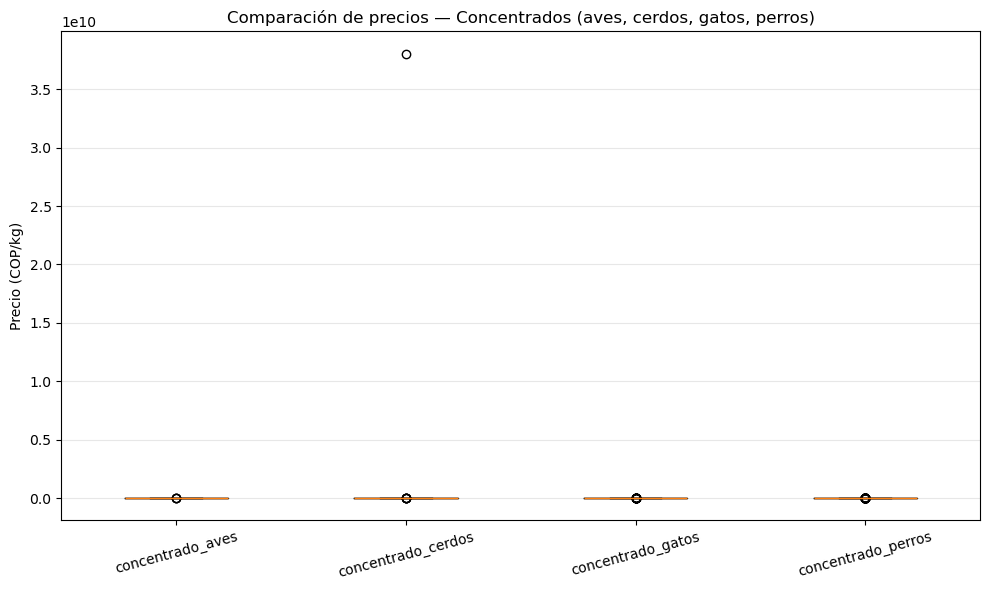

In [57]:
import matplotlib.pyplot as plt

productos_concentrados = ['concentrado_aves', 'concentrado_cerdos', 
                           'concentrado_gatos', 'concentrado_perros']

datos_boxplot = [df[df['producto'] == p]['precio_cop_kg'].dropna() for p in productos_concentrados]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(datos_boxplot, labels=productos_concentrados, showfliers=True)
ax.set_ylabel('Precio (COP/kg)')
ax.set_title('Comparación de precios — Concentrados (aves, cerdos, gatos, perros)')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [65]:
import sqlite3, pandas as pd

con = sqlite3.connect("mercado_hch.db")

df_cerdos = pd.read_sql("""
    SELECT archivo_pdf, fecha, cantidad_kg, total_cop, precio_cop_kg,
           ROUND(total_cop / cantidad_kg, 2) AS precio_recalculado
    FROM bmc_precios
    WHERE producto = 'concentrado_cerdos'
    ORDER BY precio_cop_kg DESC
    LIMIT 10
""", con)

print(df_cerdos.to_string(index=False))
con.close()

                                                           archivo_pdf      fecha  cantidad_kg    total_cop  precio_cop_kg  precio_recalculado
              BDR_59_DIARIO DE RUEDA N- 59 DEL 27 DE MARZO DE 2026.pdf 2026-03-27  21015662.00 0.000000e+00   3.805504e+10                0.00
BDR_220_BOLETIN DIARIO DE RUEDA N- 220 DEL 23 DE NOVIEMBRE DE 2022.pdf 2022-11-23    451537.00 1.350730e+09   2.991400e+03             2991.40
         BDR_1_BOLETIN DIARIO DE RUEDA N- 1 DEL 2 DE ENERO DE 2023.pdf 2023-01-02    398921.00 1.153140e+09   2.890650e+03             2890.65
BDR_237_BOLETIN DIARIO DE RUEDA N- 237 DEL 19 DE DICIEMBRE DE 2022.pdf 2022-12-19   1586560.00 4.532066e+09   2.856540e+03             2856.54
               BDR_84_DIARIO DE RUEDA N- 84 DEL 04 DE MAYO DE 2023.pdf 2023-05-04   2636969.00 7.464665e+09   2.830770e+03             2830.77
BDR_217_BOLETIN DIARIO DE RUEDA N- 217 DEL 18 DE NOVIEMBRE DE 2022.pdf 2022-11-18   1582897.00 4.474758e+09   2.826940e+03             2826.94

In [67]:
import sqlite3, pandas as pd

con = sqlite3.connect("mercado_hch.db")

# Traer la TRM real del 27 de marzo de 2026
trm_fecha = pd.read_sql(
    "SELECT trm_cop_usd FROM trm_diaria WHERE fecha = '2026-03-27'", con
)['trm_cop_usd'].iloc[0]

precio_cop_real = 1810.79
precio_usd_ton_real = round((precio_cop_real * 1000) / trm_fecha, 2)

con.execute("""
    UPDATE bmc_precios
    SET cantidad_kg = 21015662.00,
        total_cop = 38055039361.68,
        precio_cop_kg = ?,
        precio_usd_ton = ?
    WHERE producto = 'concentrado_cerdos'
      AND archivo_pdf LIKE '%BDR_59%'
      AND fecha = '2026-03-27'
""", (precio_cop_real, precio_usd_ton_real))

con.commit()
print(f"✅ Corregido: precio_cop_kg={precio_cop_real}, precio_usd_ton={precio_usd_ton_real} (TRM={trm_fecha})")
con.close()

✅ Corregido: precio_cop_kg=1810.79, precio_usd_ton=492.69 (TRM=3675.29)


In [69]:
con = sqlite3.connect("mercado_hch.db")
check = pd.read_sql("""
    SELECT fecha, archivo_pdf, cantidad_kg, total_cop, precio_cop_kg, precio_usd_ton
    FROM bmc_precios
    WHERE producto = 'concentrado_cerdos' AND archivo_pdf LIKE '%BDR_59%'
""", con)
print(check.to_string(index=False))
con.close()

     fecha                                              archivo_pdf  cantidad_kg    total_cop  precio_cop_kg  precio_usd_ton
2024-03-26 BDR_59_DIARIO DE RUEDA N- 59 DEL 26 DE MARZO DE 2024.pdf   10013357.0 1.909804e+10        1907.26          488.85
2025-03-27 BDR_59_DIARIO DE RUEDA N- 59 DEL 27 DE MARZO DE 2025.pdf    3166823.0 6.680211e+09        2109.44          510.58
2026-03-27 BDR_59_DIARIO DE RUEDA N- 59 DEL 27 DE MARZO DE 2026.pdf   21015662.0 3.805504e+10        1810.79          492.69


In [71]:
import sqlite3, pandas as pd

con = sqlite3.connect("mercado_hch.db")

df = pd.read_sql("""
    SELECT producto, fecha, archivo_pdf, cantidad_kg, total_cop, precio_cop_kg
    FROM bmc_precios
    WHERE precio_cop_kg IS NOT NULL AND total_cop IS NOT NULL
""", con)

# Huella del bug: precio_cop_kg se parece demasiado a total_cop (razón > 1000)
df['razon'] = df['precio_cop_kg'] / df['total_cop'].replace(0, pd.NA)
sospechosos = df[df['razon'] > 0.5]  # el precio no debería acercarse al total

print(f"Filas sospechosas encontradas: {len(sospechosos)}")
print(sospechosos[['producto','fecha','archivo_pdf','cantidad_kg','total_cop','precio_cop_kg']].to_string(index=False))

con.close()

Filas sospechosas encontradas: 5
             producto      fecha                                                        archivo_pdf  cantidad_kg  total_cop  precio_cop_kg
subproductos_carnicos 2023-06-22         BDR_116_DIARIO DE RUEDA N- 116 DEL 22 DE JUNIO DE 2023.pdf         1.00  12000.000       12000.00
subproductos_carnicos 2025-12-26     BDR_242_DIARIO DE RUEDA N- 242 DEL 26 DE DICIEMBRE DE 2025.pdf         1.60   8000.000        5000.00
    concentrado_gatos 2023-07-06         BDR_125_DIARIO DE RUEDA N- 125 DEL 06 DE JULIO DE 2023.pdf         1.00   3016.000        3016.00
             sebo_res 2026-07-21 BDR_132_BOLETÍN DIARIO DE RUEDA N- 132 DEL 21 DE JULIO DE 2026.pdf         1.05    353.000         336.19
subproductos_carnicos 2026-04-06           BDR_63_DIARIO DE RUEDA N- 63 DEL 06 DE ABRIL DE 2026.pdf        72.80      1.637          22.49


In [73]:
import sqlite3

con = sqlite3.connect("mercado_hch.db")
con.execute("""
    UPDATE bmc_precios
    SET total_cop = 1637.00
    WHERE producto = 'subproductos_carnicos'
      AND archivo_pdf LIKE '%BDR_63%'
      AND fecha = '2026-04-06'
""")
con.commit()
print("✅ total_cop corregido")
con.close()

✅ total_cop corregido


C:\Users\nvind\AppData\Local\Temp\ipykernel_7244\3736224701.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_boxplot, labels=productos_concentrados, showfliers=True)


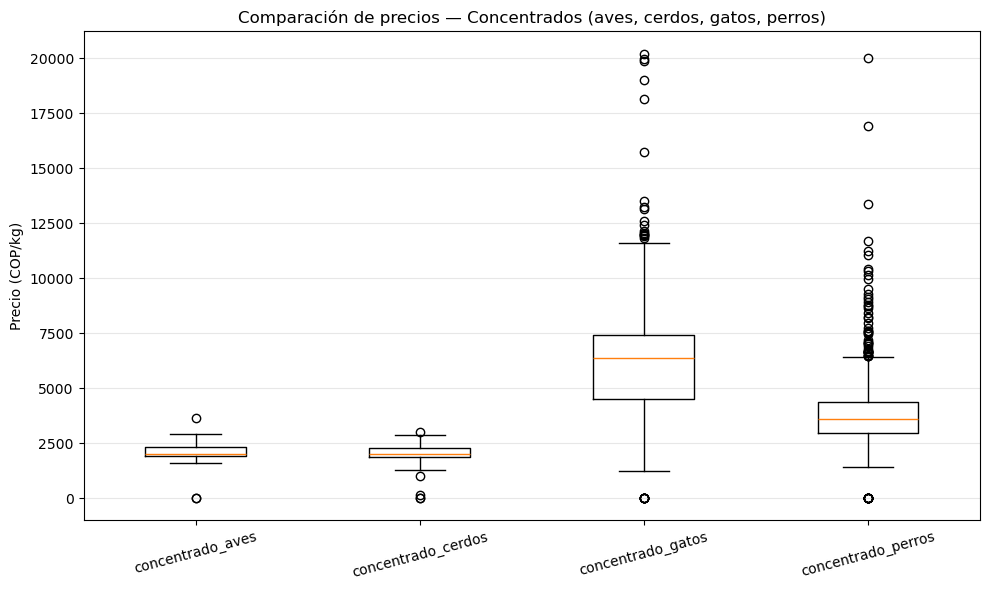

In [75]:
import matplotlib.pyplot as plt

productos_concentrados = ['concentrado_aves', 'concentrado_cerdos', 
                           'concentrado_gatos', 'concentrado_perros']

datos_boxplot = [df[df['producto'] == p]['precio_cop_kg'].dropna() for p in productos_concentrados]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(datos_boxplot, labels=productos_concentrados, showfliers=True)
ax.set_ylabel('Precio (COP/kg)')
ax.set_title('Comparación de precios — Concentrados (aves, cerdos, gatos, perros)')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [81]:
import sqlite3, pandas as pd

con = sqlite3.connect("mercado_hch.db")

df_bajos = pd.read_sql("""
    SELECT producto, fecha, archivo_pdf, cantidad_kg, total_cop, precio_cop_kg
    FROM bmc_precios
    WHERE producto IN ('concentrado_aves', 'concentrado_cerdos', 'concentrado_perros')
      AND precio_cop_kg < 50
    ORDER BY producto, fecha
""", con)

print(f"Filas con precio_cop_kg < 50: {len(df_bajos)}")
print(df_bajos.to_string(index=False))

Filas con precio_cop_kg < 50: 17
          producto      fecha                                                                  archivo_pdf  cantidad_kg  total_cop  precio_cop_kg
  concentrado_aves 2026-04-27                     BDR_78_DIARIO DE RUEDA N- 78 DEL 27 DE ABRIL DE 2026.pdf         25.0     69.048        2.76192
  concentrado_aves 2026-07-22           BDR_133_BOLETÍN DIARIO DE RUEDA N- 133 DEL 22 DE JULIO DE 2026.pdf         25.0     76.190        3.04760
concentrado_cerdos 2026-07-14 BDR_128_ALCANCE A BOLETÍN DIARIO DE RUEDA N- 128 DEL 14 DE JULIO DE 2026.pdf        200.0    375.000        1.87500
concentrado_cerdos 2026-07-15                   BDR_128_DIARIO DE RUEDA N- 128 DEL 15 DE JULIO DE 2026.pdf        200.0    375.000        1.87500
concentrado_perros 2026-03-31                     BDR_61_DIARIO DE RUEDA N- 61 DEL 31 DE MARZO DE 2026.pdf        207.0    845.656        4.08529
concentrado_perros 2026-04-09                     BDR_66_DIARIO DE RUEDA N- 66 DEL 09 DE AB

In [85]:
import sqlite3

con = sqlite3.connect("mercado_hch.db")
cur = con.cursor()

archivos_afectados = [
    ('concentrado_aves', '2026-04-27', 'BDR_78%'),
    ('concentrado_aves', '2026-07-22', 'BDR_133%'),
    ('concentrado_cerdos', '2026-07-14', 'BDR_128_ALCANCE%'),
    ('concentrado_cerdos', '2026-07-15', 'BDR_128_DIARIO%'),
    ('concentrado_perros', '2026-03-31', 'BDR_61%'),
    ('concentrado_perros', '2026-04-09', 'BDR_66%'),
    ('concentrado_perros', '2026-05-14', 'BDR_90%'),
    ('concentrado_perros', '2026-06-03', 'BDR_103%'),
    ('concentrado_perros', '2026-06-05', 'BDR_105%'),
    ('concentrado_perros', '2026-06-12', 'BDR_109%'),
    ('concentrado_perros', '2026-06-18', 'BDR_112%'),
    ('concentrado_perros', '2026-06-19', 'BDR_113%'),
    ('concentrado_perros', '2026-06-23', 'BDR_115%'),
    ('concentrado_perros', '2026-06-25', 'BDR_117%'),
    ('concentrado_perros', '2026-06-26', 'BDR_118%'),
    ('concentrado_perros', '2026-07-01', 'BDR_120%'),
    ('concentrado_perros', '2026-07-23', 'BDR_134%'),
]

for producto, fecha, patron in archivos_afectados:
    cur.execute(f"""
        UPDATE bmc_precios
        SET total_cop = total_cop * 1000,
            precio_cop_kg = precio_cop_kg * 1000
        WHERE producto = ? AND fecha = ? AND archivo_pdf LIKE ?
    """, (producto, fecha, patron))

con.commit()
print(f"✅ {con.total_changes} filas corregidas ×1000")
con.close()

✅ 17 filas corregidas ×1000


In [87]:
con = sqlite3.connect("mercado_hch.db")

df_fix = pd.read_sql("""
    SELECT b.id, b.precio_cop_kg, t.trm_cop_usd
    FROM bmc_precios b
    JOIN trm_diaria t ON b.fecha = t.fecha
    WHERE b.producto IN ('concentrado_aves','concentrado_cerdos','concentrado_perros')
      AND b.fecha >= '2026-01-01'
      AND b.precio_cop_kg < 100000  -- ya corregidas, evita tocar otras
""", con)

df_fix['precio_usd_ton_nuevo'] = round((df_fix['precio_cop_kg'] * 1000) / df_fix['trm_cop_usd'], 2)

cur = con.cursor()
for _, row in df_fix.iterrows():
    cur.execute("UPDATE bmc_precios SET precio_usd_ton = ? WHERE id = ?",
                (row['precio_usd_ton_nuevo'], row['id']))
con.commit()
print(f"✅ {len(df_fix)} filas con precio_usd_ton recalculado")
con.close()

✅ 198 filas con precio_usd_ton recalculado


In [89]:
con = sqlite3.connect("mercado_hch.db")
check = pd.read_sql("""
    SELECT producto, fecha, archivo_pdf, total_cop, precio_cop_kg, precio_usd_ton
    FROM bmc_precios
    WHERE producto = 'concentrado_aves' AND archivo_pdf LIKE 'BDR_78%' AND fecha = '2026-04-27'
""", con)
print(check.to_string(index=False))
con.close()

        producto      fecha                                              archivo_pdf  total_cop  precio_cop_kg  precio_usd_ton
concentrado_aves 2026-04-27 BDR_78_DIARIO DE RUEDA N- 78 DEL 27 DE ABRIL DE 2026.pdf    69048.0        2761.92          777.75


C:\Users\nvind\AppData\Local\Temp\ipykernel_7244\3736224701.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_boxplot, labels=productos_concentrados, showfliers=True)


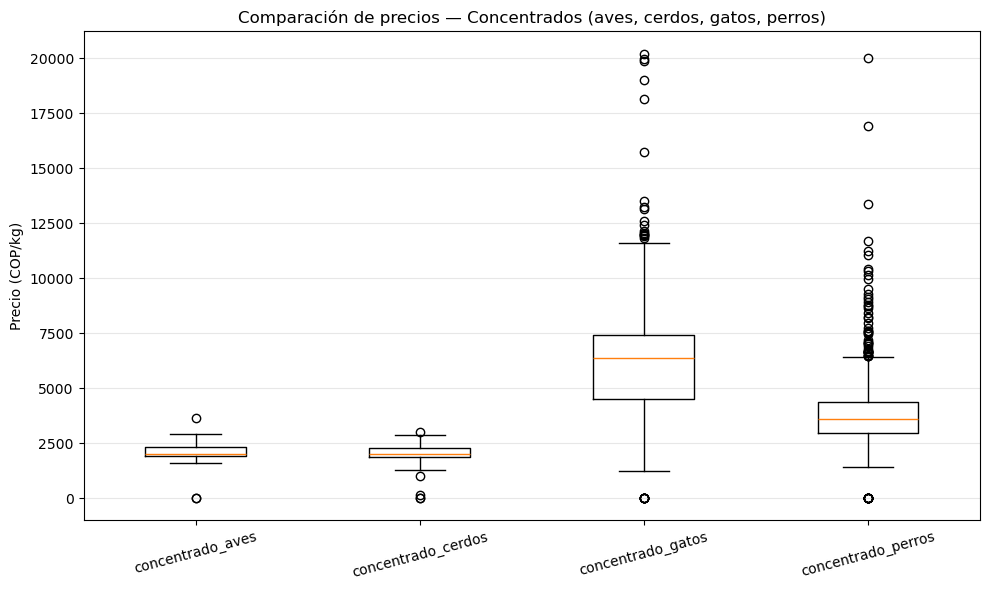

In [91]:
import matplotlib.pyplot as plt

productos_concentrados = ['concentrado_aves', 'concentrado_cerdos', 
                           'concentrado_gatos', 'concentrado_perros']

datos_boxplot = [df[df['producto'] == p]['precio_cop_kg'].dropna() for p in productos_concentrados]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(datos_boxplot, labels=productos_concentrados, showfliers=True)
ax.set_ylabel('Precio (COP/kg)')
ax.set_title('Comparación de precios — Concentrados (aves, cerdos, gatos, perros)')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

C:\Users\nvind\AppData\Local\Temp\ipykernel_7244\2677246344.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_boxplot, labels=productos, showfliers=True)


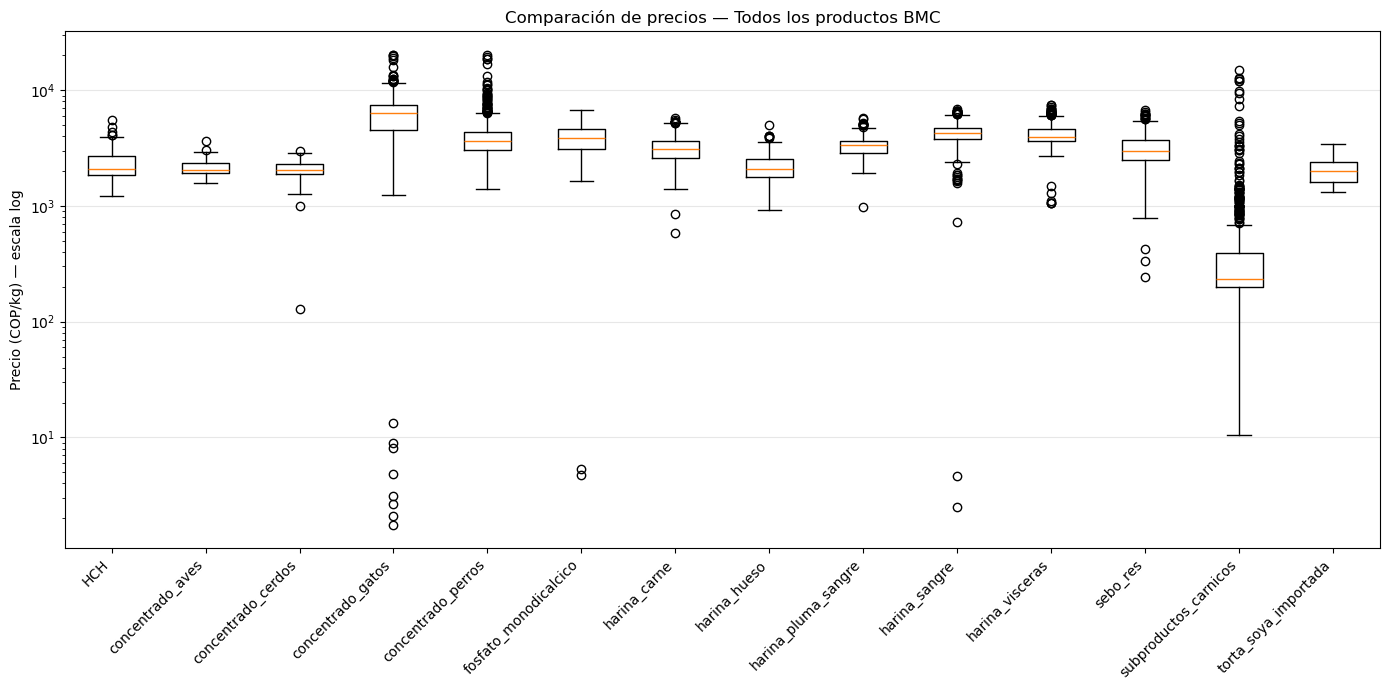

In [93]:
import sqlite3, pandas as pd
import matplotlib.pyplot as plt

con = sqlite3.connect("mercado_hch.db")
df = pd.read_sql("""
    SELECT producto, precio_cop_kg
    FROM bmc_precios
    WHERE precio_cop_kg IS NOT NULL
""", con)
con.close()

productos = sorted(df['producto'].unique())
datos_boxplot = [df[df['producto'] == p]['precio_cop_kg'].dropna() for p in productos]

fig, ax = plt.subplots(figsize=(14, 7))
ax.boxplot(datos_boxplot, labels=productos, showfliers=True)
ax.set_ylabel('Precio (COP/kg) — escala log')
ax.set_yscale('log')
ax.set_title('Comparación de precios — Todos los productos BMC')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [95]:
con = sqlite3.connect("mercado_hch.db")
df_bajos = pd.read_sql("""
    SELECT producto, fecha, archivo_pdf, cantidad_kg, total_cop, precio_cop_kg
    FROM bmc_precios
    WHERE producto IN ('concentrado_gatos', 'fosfato_monodicalcico', 'harina_sangre')
      AND precio_cop_kg < 50
    ORDER BY producto, fecha
""", con)
print(f"Filas encontradas: {len(df_bajos)}")
print(df_bajos.to_string(index=False))
con.close()

Filas encontradas: 12
             producto      fecha                                                archivo_pdf  cantidad_kg  total_cop  precio_cop_kg
    concentrado_gatos 2026-02-18 BDR_33_DIARIO DE RUEDA N- 33 DEL 18 DE FEBRERO DE 2026.pdf       144.00    693.105        4.81323
    concentrado_gatos 2026-04-01  BDR_62_DIARIO DE RUEDA N- 62 DEL 01 DE ABRIL  DE 2026.pdf       179.00    476.277        2.66077
    concentrado_gatos 2026-05-14    BDR_90_DIARIO DE RUEDA N- 90 DEL 14 DE MAYO DE 2026.pdf        79.49    647.268        8.14296
    concentrado_gatos 2026-06-03 BDR_103_DIARIO DE RUEDA N- 103 DEL 03 DE JUNIO DE 2026.pdf       296.00    620.264        2.09549
    concentrado_gatos 2026-06-17 BDR_111_DIARIO DE RUEDA N- 111 DEL 17 DE JUNIO DE 2026.pdf        81.00    252.070        3.11198
    concentrado_gatos 2026-07-02 BDR_121_DIARIO DE RUEDA N- 121 DEL 02 DE JULIO DE 2026.pdf        20.64    183.300        8.88081
    concentrado_gatos 2026-07-07 BDR_124_DIARIO DE RUEDA N- 1

In [97]:
import sqlite3, pandas as pd

con = sqlite3.connect("mercado_hch.db")
cur = con.cursor()

filas_afectadas = [
    ('concentrado_gatos', '2026-02-18', 'BDR_33%'),
    ('concentrado_gatos', '2026-04-01', 'BDR_62%'),
    ('concentrado_gatos', '2026-05-14', 'BDR_90%'),
    ('concentrado_gatos', '2026-06-03', 'BDR_103%'),
    ('concentrado_gatos', '2026-06-17', 'BDR_111%'),
    ('concentrado_gatos', '2026-07-02', 'BDR_121%'),
    ('concentrado_gatos', '2026-07-07', 'BDR_124%'),
    ('concentrado_gatos', '2026-07-09', 'BDR_126%'),
    ('fosfato_monodicalcico', '2026-03-30', 'BDR_60%'),
    ('fosfato_monodicalcico', '2026-06-10', 'BDR_107%'),
    ('harina_sangre', '2026-04-01', 'BDR_62%'),
    ('harina_sangre', '2026-06-11', 'BDR_108%'),
]

for producto, fecha, patron in filas_afectadas:
    cur.execute("""
        UPDATE bmc_precios
        SET total_cop = total_cop * 1000,
            precio_cop_kg = precio_cop_kg * 1000
        WHERE producto = ? AND fecha = ? AND archivo_pdf LIKE ?
    """, (producto, fecha, patron))

con.commit()
print(f"✅ {con.total_changes} filas corregidas ×1000")

# Recalcular precio_usd_ton con TRM real para estas mismas filas
df_fix = pd.read_sql("""
    SELECT b.id, b.precio_cop_kg, t.trm_cop_usd
    FROM bmc_precios b
    JOIN trm_diaria t ON b.fecha = t.fecha
    WHERE (b.producto, b.fecha) IN (
        ('concentrado_gatos','2026-02-18'), ('concentrado_gatos','2026-04-01'),
        ('concentrado_gatos','2026-05-14'), ('concentrado_gatos','2026-06-03'),
        ('concentrado_gatos','2026-06-17'), ('concentrado_gatos','2026-07-02'),
        ('concentrado_gatos','2026-07-07'), ('concentrado_gatos','2026-07-09'),
        ('fosfato_monodicalcico','2026-03-30'), ('fosfato_monodicalcico','2026-06-10'),
        ('harina_sangre','2026-04-01'), ('harina_sangre','2026-06-11')
    )
""", con)

df_fix['precio_usd_ton_nuevo'] = round((df_fix['precio_cop_kg'] * 1000) / df_fix['trm_cop_usd'], 2)
for _, row in df_fix.iterrows():
    cur.execute("UPDATE bmc_precios SET precio_usd_ton = ? WHERE id = ?",
                (row['precio_usd_ton_nuevo'], row['id']))
con.commit()
print(f"✅ {len(df_fix)} filas con precio_usd_ton recalculado")
con.close()

✅ 12 filas corregidas ×1000
✅ 12 filas con precio_usd_ton recalculado


C:\Users\nvind\AppData\Local\Temp\ipykernel_7244\3770839519.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_boxplot, labels=productos, showfliers=True)


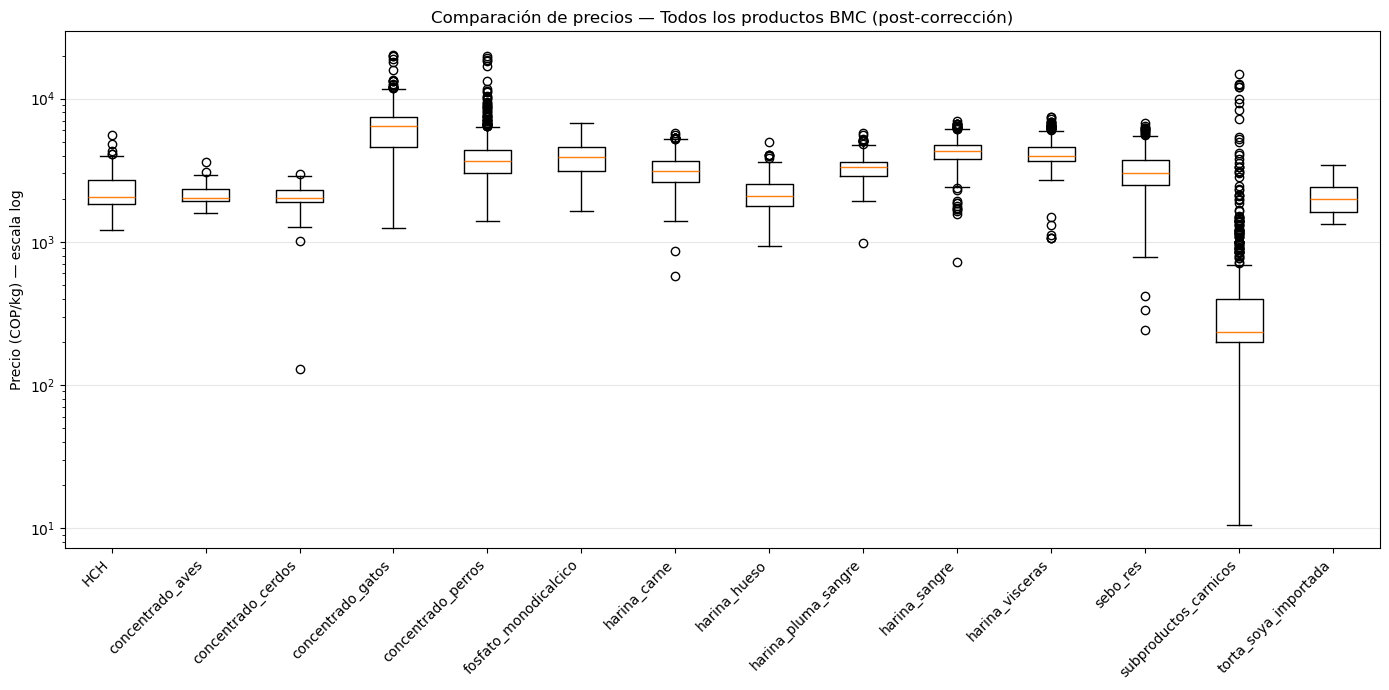

In [99]:
con = sqlite3.connect("mercado_hch.db")
df = pd.read_sql("""
    SELECT producto, precio_cop_kg
    FROM bmc_precios
    WHERE precio_cop_kg IS NOT NULL
""", con)
con.close()

productos = sorted(df['producto'].unique())
datos_boxplot = [df[df['producto'] == p]['precio_cop_kg'].dropna() for p in productos]

fig, ax = plt.subplots(figsize=(14, 7))
ax.boxplot(datos_boxplot, labels=productos, showfliers=True)
ax.set_ylabel('Precio (COP/kg) — escala log')
ax.set_yscale('log')
ax.set_title('Comparación de precios — Todos los productos BMC (post-corrección)')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [101]:
import sqlite3, pandas as pd

con = sqlite3.connect("mercado_hch.db")
df_check = pd.read_sql("""
    SELECT producto, fecha, archivo_pdf, cantidad_kg, total_cop, precio_cop_kg
    FROM bmc_precios
    WHERE producto = 'concentrado_cerdos' AND precio_cop_kg BETWEEN 50 AND 300
    ORDER BY fecha
""", con)
print(df_check.to_string(index=False))
con.close()

          producto      fecha                                             archivo_pdf  cantidad_kg  total_cop  precio_cop_kg
concentrado_cerdos 2026-05-14 BDR_90_DIARIO DE RUEDA N- 90 DEL 14 DE MAYO DE 2026.pdf          6.0     1986.0          129.0


In [103]:
import sqlite3, pandas as pd

con = sqlite3.connect("mercado_hch.db")

# TRM real del 14 de mayo de 2026
trm_fecha = pd.read_sql("SELECT trm_cop_usd FROM trm_diaria WHERE fecha = '2026-05-14'", con)['trm_cop_usd'].iloc[0]
precio_real = 1942.10
precio_usd_ton_real = round((precio_real * 1000) / trm_fecha, 2)

con.execute("""
    UPDATE bmc_precios
    SET cantidad_kg = 1986129.00,
        total_cop = 3857261648.08,
        precio_cop_kg = ?,
        precio_usd_ton = ?
    WHERE producto = 'concentrado_cerdos'
      AND archivo_pdf LIKE 'BDR_90%'
      AND fecha = '2026-05-14'
""", (precio_real, precio_usd_ton_real))

con.commit()
print(f"✅ Corregido: precio_cop_kg={precio_real}, precio_usd_ton={precio_usd_ton_real} (TRM={trm_fecha})")
con.close()

✅ Corregido: precio_cop_kg=1942.1, precio_usd_ton=511.76 (TRM=3794.91)


C:\Users\nvind\AppData\Local\Temp\ipykernel_7244\3770839519.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_boxplot, labels=productos, showfliers=True)


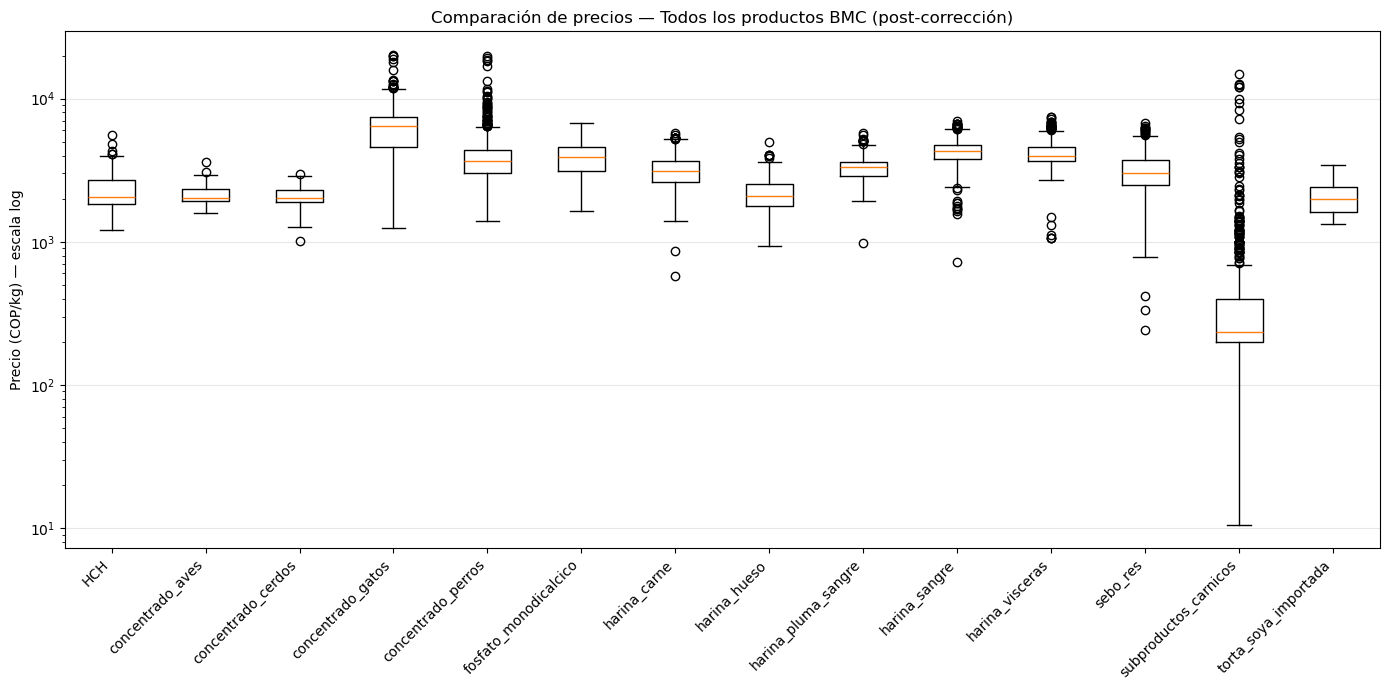

In [105]:
con = sqlite3.connect("mercado_hch.db")
df = pd.read_sql("""
    SELECT producto, precio_cop_kg
    FROM bmc_precios
    WHERE precio_cop_kg IS NOT NULL
""", con)
con.close()

productos = sorted(df['producto'].unique())
datos_boxplot = [df[df['producto'] == p]['precio_cop_kg'].dropna() for p in productos]

fig, ax = plt.subplots(figsize=(14, 7))
ax.boxplot(datos_boxplot, labels=productos, showfliers=True)
ax.set_ylabel('Precio (COP/kg) — escala log')
ax.set_yscale('log')
ax.set_title('Comparación de precios — Todos los productos BMC (post-corrección)')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\nvind\AppData\Local\Temp\ipykernel_7244\1304091868.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(labelcolor='white', frameon=False)


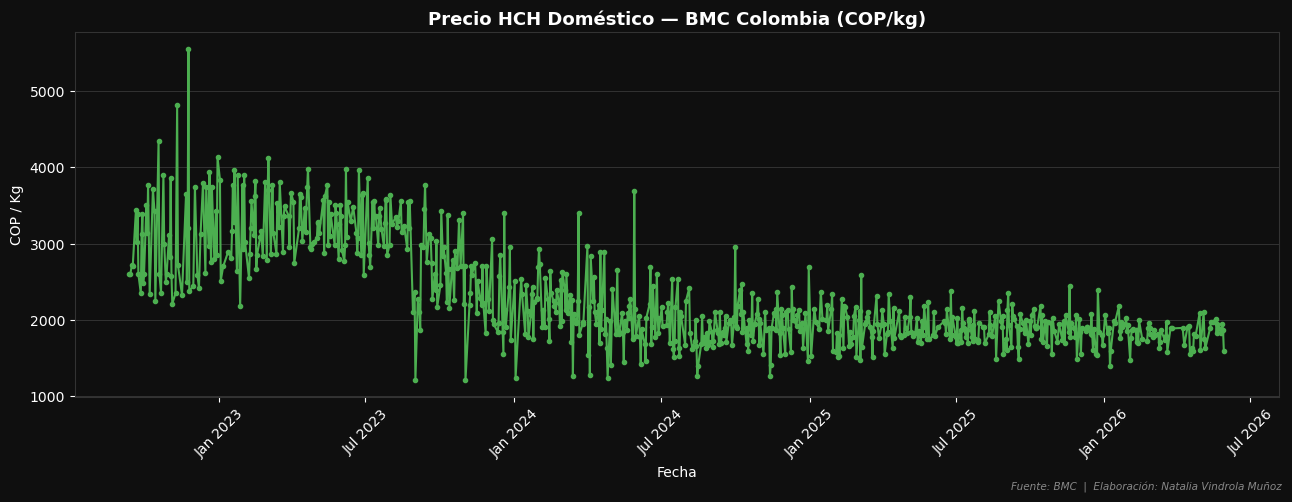

✅ 739 días | Precio promedio: $2307 COP/kg


In [107]:
# ── CELDA 9 — Gráfico precio HCH en el tiempo ────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

with sqlite3.connect(DB_PATH) as con:
    df_hch = pd.read_sql("""
        SELECT fecha, precio_usd_ton, precio_cop_kg
        FROM bmc_precios WHERE producto = 'HCH' ORDER BY fecha
    """, con)

if df_hch.empty:
    print("⚠️  No hay datos de HCH. Ejecuta primero las celdas 6 y 7.")
else:
    df_hch['fecha'] = pd.to_datetime(df_hch['fecha'])
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.set_facecolor('#0F0F0F')
    fig.patch.set_facecolor('#0F0F0F')
    ax.plot(df_hch['fecha'], df_hch['precio_cop_kg'],
            color='#4CAF50', linewidth=1.5, marker='o', markersize=3)
    ax.set_title('Precio HCH Doméstico — BMC Colombia (COP/kg)',
                 color='white', fontsize=13, fontweight='bold')
    ax.set_xlabel('Fecha', color='white')
    ax.set_ylabel('COP / Kg', color='white')
    ax.tick_params(colors='white')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)
    ax.legend(labelcolor='white', frameon=False)
    ax.yaxis.grid(True, color='#333', linewidth=0.7)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')
    fig.text(0.99, 0.01, 'Fuente: BMC  |  Elaboración: Natalia Vindrola Muñoz',
             ha='right', fontsize=7.5, color='#888', style='italic')
    plt.tight_layout()
    plt.savefig('bmc_hch_precio.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"✅ {len(df_hch)} días | Precio promedio: ${df_hch['precio_cop_kg'].mean():.0f} COP/kg")

In [11]:
ruta_prueba = CARPETA_PDF / "BDR_103_DIARIO DE RUEDA N- 103 DEL 03 DE JUNIO DE 2026.pdf"
registros_reales = extraer_pdf_completo(str(ruta_prueba))
print(f"extraer_pdf_completo() devuelve: {len(registros_reales)} registros")
for r in registros_reales:
    print(f"  {r['producto']}: {r['precio_cop_kg']}")

extraer_pdf_completo() devuelve: 7 registros
  torta_soya_importada: 1507.98
  sebo_res: 2646.57
  HCH: 1791.08
  subproductos_carnicos: 11547.19
  concentrado_perros: 3338.21
  harina_sangre: 5250.0
  concentrado_gatos: 7404.38


In [13]:
con = sqlite3.connect(DB_PATH)
pdfs_hueco = pd.read_sql("""
    SELECT DISTINCT archivo_pdf
    FROM bmc_precios
    WHERE fecha BETWEEN '2026-06-03' AND '2026-07-23'
""", con)['archivo_pdf'].tolist()
con.close()

print(f"PDFs a reprocesar: {len(pdfs_hueco)}")

total_nuevos = 0
for nombre in pdfs_hueco:
    ruta = CARPETA_PDF / nombre
    if not ruta.exists():
        print(f"  ⚠️ No encontrado en disco: {nombre}")
        continue
    registros = extraer_pdf_completo(str(ruta))
    nuevos = guardar_en_db(registros)
    total_nuevos += nuevos
    print(f"  ✅ {nombre[:60]} → {nuevos} filas nuevas")

print(f"\n🎉 Total filas nuevas agregadas: {total_nuevos}")

PDFs a reprocesar: 22
  ✅ BDR_103_DIARIO DE RUEDA N- 103 DEL 03 DE JUNIO DE 2026.pdf → 5 filas nuevas
  ✅ BDR_105_DIARIO DE RUEDA N- 105 DEL 05 DE JUNIO DE 2026.pdf → 9 filas nuevas
  ✅ BDR_107_DIARIO DE RUEDA N- 107 DEL 10 DE JUNIO DE 2026.pdf → 7 filas nuevas
  ✅ BDR_108_DIARIO DE RUEDA N- 108 DEL 11 DE JUNIO DE 2026.pdf → 11 filas nuevas
  ✅ BDR_109_DIARIO DE RUEDA N- 109 DEL 12 DE JUNIO DE 2026.pdf → 6 filas nuevas
  ✅ BDR_111_DIARIO DE RUEDA N- 111 DEL 17 DE JUNIO DE 2026.pdf → 5 filas nuevas
  ✅ BDR_112_DIARIO DE RUEDA N- 112 DEL 18 DE JUNIO DE 2026.pdf → 8 filas nuevas
  ✅ BDR_113_DIARIO DE RUEDA N- 113 DEL 19 DE JUNIO DE 2026.pdf → 9 filas nuevas
  ✅ BDR_114_DIARIO DE RUEDA N- 114 DEL 22 DE JUNIO DE 2026.pdf → 7 filas nuevas
  ✅ BDR_115_DIARIO DE RUEDA N- 115 DEL 23 DE JUNIO DE 2026.pdf → 7 filas nuevas
  ✅ BDR_117_DIARIO DE RUEDA N- 117 DEL 25 DE JUNIO DE 2026.pdf → 10 filas nuevas
  ✅ BDR_118_DIARIO DE RUEDA N- 118 DEL 26 DE JUNIO DE 2026.pdf → 5 filas nuevas
  ✅ BDR_120_DIAR

In [17]:
con = sqlite3.connect(DB_PATH)

cobertura = pd.read_sql("""
    SELECT fecha, COUNT(DISTINCT producto) AS n_productos
    FROM bmc_precios
    WHERE fecha BETWEEN '2026-06-03' AND '2026-07-23'
    GROUP BY fecha ORDER BY fecha
""", con)
print(cobertura.to_string(index=False))

hch_check = pd.read_sql("""
    SELECT fecha, precio_cop_kg FROM bmc_precios
    WHERE producto = 'HCH' AND fecha BETWEEN '2026-06-03' AND '2026-07-23'
    ORDER BY fecha
""", con)
print(f"\nRegistros de HCH en el hueco: {len(hch_check)}")
print(hch_check.to_string(index=False))

con.close()

     fecha  n_productos
2026-06-03            7
2026-06-05           10
2026-06-10            8
2026-06-11           12
2026-06-12            7
2026-06-17            6
2026-06-18            9
2026-06-19           10
2026-06-22            8
2026-06-23            8
2026-06-25           11
2026-06-26            6
2026-07-01            9
2026-07-02            2
2026-07-07            2
2026-07-08            4
2026-07-09           10
2026-07-14            7
2026-07-15            7
2026-07-21            8
2026-07-22            9
2026-07-23           10

Registros de HCH en el hueco: 15
     fecha  precio_cop_kg
2026-06-03        1791.08
2026-06-10        1988.95
2026-06-11        1804.76
2026-06-12        1893.28
2026-06-18        1874.94
2026-06-19        1855.62
2026-06-22        1990.10
2026-06-23        1602.95
2026-06-25        1951.17
2026-06-26        1793.91
2026-07-09        1873.77
2026-07-14        1988.06
2026-07-15        1988.06
2026-07-21        2050.00
2026-07-23        1983.4